Mounted at /content/drive
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.5 MB/s eta 0:00:00
Loading dataset from:
/content/drive/MyDrive/dados_pesquisa_msr_v3/master_dataset/master_github_repositories.parquet

--- Starting MSR Data Cleaning and Feature Engineering ---
Total Repositories Analyzed: 45003
Global Abandonment Rate: 72.60%

--- RQ1: Adoption Dynamics (Kruskal-Wallis & Games-Howell) ---

Analyzed Metric: STARS
Kruskal-Wallis H: 3798.99, p-value: 0.00000e+00

Post-hoc Pairwise Comparisons:
               A              B          pval       diff
0   ARIMA_FAMILY  HYBRID_FAMILY  2.152095e-01   0.916175
1   ARIMA_FAMILY    LSTM_FAMILY  2.465269e-06 -16.758996
2  HYBRID_FAMILY    LSTM_FAMILY  5.509511e-07 -17.675171

Analyzed Metric: FORKS
Kruskal-Wallis H: 2113.83, 

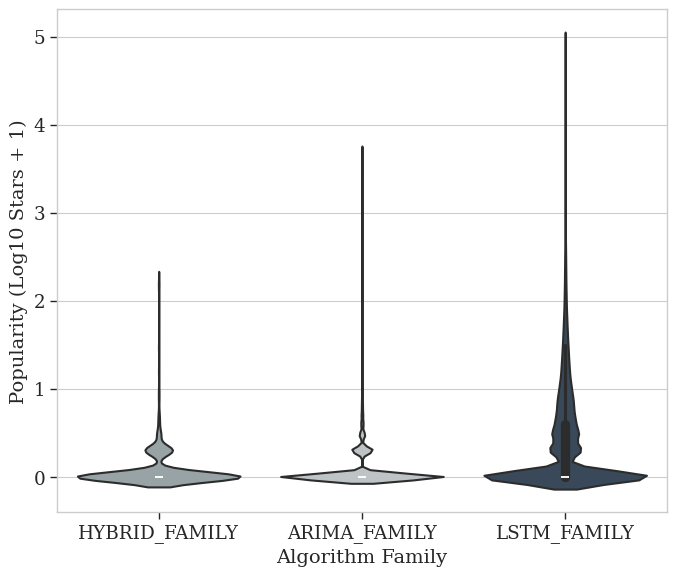

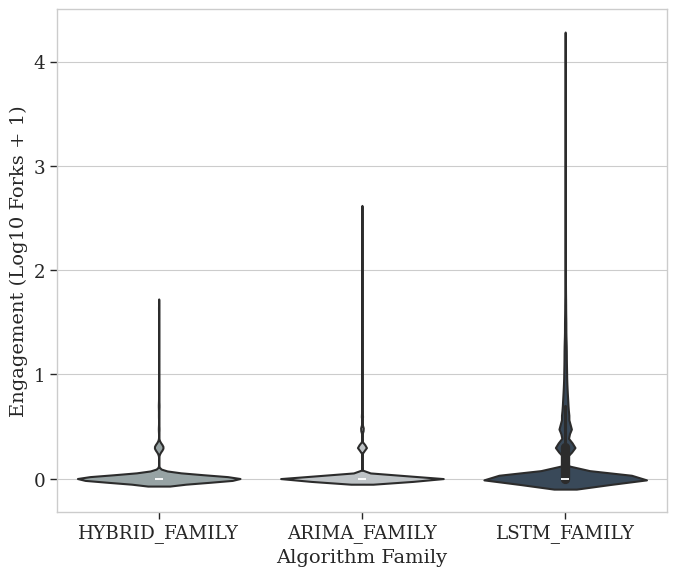

RQ1 figures saved successfully.

--- RQ2: Kaplan-Meier Survival Analysis ---
Median Survival Time (ARIMA_FAMILY): 0.02 months
Median Survival Time (HYBRID_FAMILY): 2.08 months
Median Survival Time (LSTM_FAMILY): 0.19 months


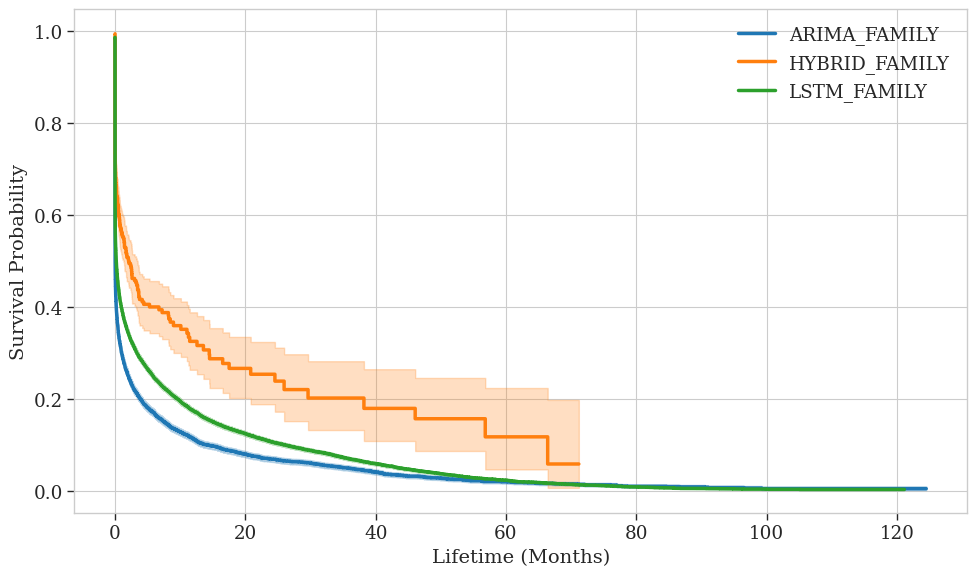


--- RQ3: Cox Proportional-Hazards Model ---

Cox Model Summary (Hazard Ratios):


<lifelines.CoxPHFitter: fitted with 45003 total observations, 12329 right-censored observations>
             duration col = 'lifetime_months'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 45003
number of events observed = 32674
   partial log-likelihood = -313906.81
         time fit was run = 2026-06-23 13:51:21 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                          
log_stars                         -0.13      0.87      0.01           -0.15           -0.12                0.86                0.89
log_forks                         -0.10      0.90      0.01           -0.12           -0.08                0.89                0.92
algorithm_class_HYBRID_FAMILY     -0.58      0.56      0.05           -0.68           -0.48                0.51                0.62
algorithm_class_LSTM_FAMILY       -0.01      0.99      0.01           -0.04            0.01                0.96                1.01
language_grouped_Jupyter Notebook  0.04      1.04      0.02            0.00            0.07                1.00                1.07
language_grouped_Others           -0.27      0.76      0.03           -0.33           -0.22                0.72                0.81
language_grouped_Python           -0.15      0.86      0.02           -0.18           -0.11                0.83                0.90
language_grouped_R                 0.01      1.01      0.03           -0.06            0.08                0.94                1.08
language_grouped_Unknown           0.67      1.95      0.02            0.62            0.71                1.86                2.04

                                   cmp to      z      p  -log2(p)
covariate                                                        
log_stars                            0.00 -20.61 <0.005    310.99
log_forks                            0.00 -11.38 <0.005     97.30
algorithm_class_HYBRID_FAMILY        0.00 -11.55 <0.005    100.02
algorithm_class_LSTM_FAMILY          0.00  -1.09   0.28      1.85
language_grouped_Jupyter Notebook    0.00   2.09   0.04      4.76
language_grouped_Others              0.00  -9.61 <0.005     70.26
language_grouped_Python              0.00  -7.78 <0.005     46.99
language_grouped_R                   0.00   0.29   0.77      0.38
language_grouped_Unknown             0.00  29.29 <0.005    624.02
---
Concordance = 0.64
Partial AIC = 627831.61
log-likelihood ratio test = 4659.92 on 9 df
-log2(p) of ll-ratio test = inf

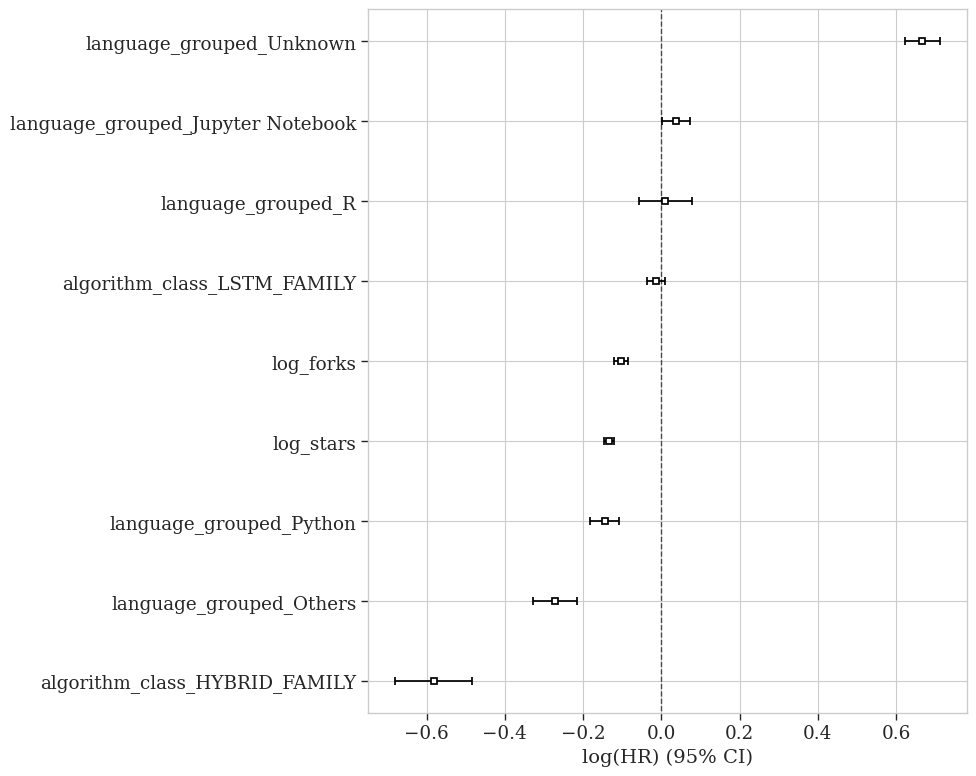


Completed!
Generated figures:
 - RQ1_Stars_Violin.png
 - RQ1_Forks_Violin.png
 - RQ2_Kaplan_Meier.png
 - RQ3_Cox_ForestPlot.png

All figures saved at 600 dpi.


In [ ]:
# ==============================================================================
# MODULE 0: PROJECT PATHS
# ==============================================================================

from pathlib import Path

DATA_PATH = Path(
    "./data/master_dataset/master_github_repositories.parquet"
)

IMG_DIR = Path("./img")
IMG_DIR.mkdir(parents=True, exist_ok=True)

# ==============================================================================
# MODULE 1: SETUP AND INSTALLATION
# ==============================================================================
!pip install -q pandas numpy scipy matplotlib seaborn lifelines pingouin pyarrow

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

from lifelines import KaplanMeierFitter, CoxPHFitter

import warnings
warnings.filterwarnings('ignore')

# IEEE / ACM Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.5)

plt.rcParams.update({
    'font.family': 'serif',
    'figure.autolayout': True,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight'
})

# ==============================================================================
# DATA LOADING AND CLEANING
# ==============================================================================
def load_and_clean_msr_data(filepath):

    print("--- Starting MSR Data Cleaning and Feature Engineering ---")

    df = pd.read_parquet(filepath)

    # Language handling
    df['language'] = df['language'].fillna('Unknown')

    top_languages = df['language'].value_counts().nlargest(5).index.tolist()

    if 'Unknown' in top_languages:
        top_languages.remove('Unknown')

    df['language_grouped'] = df['language'].apply(
        lambda x: x if x in top_languages
        else ('Unknown' if x == 'Unknown' else 'Others')
    )

    # Date conversion
    date_cols = ['created_at', 'updated_at', 'pushed_at']

    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce', utc=True)

    df = df.dropna(subset=date_cols)

    # Lifetime calculation
    df['lifetime_months'] = (
        (df['pushed_at'] - df['created_at'])
        .dt.total_seconds() / (30.44 * 24 * 3600)
    )

    df = df[df['lifetime_months'] >= 0]

    # Event definition
    data_collection_end = df['pushed_at'].max()
    cutoff_date = data_collection_end - pd.DateOffset(months=12)

    df['is_abandoned'] = (
        (df['archived'] == True) |
        (df['pushed_at'] < cutoff_date)
    )

    df['event'] = df['is_abandoned'].astype(int)

    print(f"Total Repositories Analyzed: {len(df)}")
    print(f"Global Abandonment Rate: {df['event'].mean() * 100:.2f}%\n")

    return df


# ==============================================================================
# RQ1 - ADOPTION ANALYSIS
# ==============================================================================
def analyze_adoption_differences(df):

    print("--- RQ1: Adoption Dynamics (Kruskal-Wallis & Games-Howell) ---")

    metrics = ['stars', 'forks']

    for metric in metrics:

        print(f"\nAnalyzed Metric: {metric.upper()}")

        groups = [
            group[metric].values
            for name, group in df.groupby('algorithm_class')
        ]

        stat, p_val = stats.kruskal(*groups)

        print(f"Kruskal-Wallis H: {stat:.2f}, p-value: {p_val:.5e}")

        if p_val < 0.05:

            posthoc = pg.pairwise_gameshowell(
                data=df,
                dv=metric,
                between='algorithm_class'
            )

            print("\nPost-hoc Pairwise Comparisons:")
            print(posthoc[['A', 'B', 'pval', 'diff']])


# ==============================================================================
# RQ1 - VISUALIZATION
# ==============================================================================
def plot_rq1_adoption_distribution(df):

    print("\n--- Generating RQ1 Visualizations ---")

    df_plot = df.copy()

    df_plot['log_stars'] = np.log10(df_plot['stars'] + 1)
    df_plot['log_forks'] = np.log10(df_plot['forks'] + 1)

    palette = {
        "ARIMA_FAMILY": "#bdc3c7",
        "LSTM_FAMILY": "#34495e",
        "HYBRID_FAMILY": "#95a5a6"
    }

    # ----------------------------------------------------------
    # Figure 1 - Stars
    # ----------------------------------------------------------
    plt.figure(figsize=(7,6))

    sns.violinplot(
        x='algorithm_class',
        y='log_stars',
        data=df_plot,
        inner="box",
        palette=palette,
        linewidth=1.5
    )

    plt.xlabel('Algorithm Family')
    plt.ylabel('Popularity (Log10 Stars + 1)')

    plt.tight_layout()

    plt.savefig(
        IMG_DIR / 'RQ1_Stars_Violin.png',
        format='png',
        dpi=600
    )

    plt.show()

    # ----------------------------------------------------------
    # Figure 2 - Forks
    # ----------------------------------------------------------
    plt.figure(figsize=(7,6))

    sns.violinplot(
        x='algorithm_class',
        y='log_forks',
        data=df_plot,
        inner="box",
        palette=palette,
        linewidth=1.5
    )

    plt.xlabel('Algorithm Family')
    plt.ylabel('Engagement (Log10 Forks + 1)')

    plt.tight_layout()

    plt.savefig(
        IMG_DIR / 'RQ1_Forks_Violin.png',
        format='png',
        dpi=600
    )

    plt.show()

    print("RQ1 figures saved successfully.")


# ==============================================================================
# RQ2 - SURVIVAL ANALYSIS
# ==============================================================================
def perform_survival_analysis(df):

    print("\n--- RQ2: Kaplan-Meier Survival Analysis ---")

    fig, ax = plt.subplots(figsize=(10, 6))

    kmf = KaplanMeierFitter()

    for name, grouped_df in df.groupby('algorithm_class'):

        T = grouped_df['lifetime_months']
        E = grouped_df['event']

        kmf.fit(
            T,
            event_observed=E,
            label=name
        )

        kmf.plot_survival_function(
            ax=ax,
            ci_show=True,
            linewidth=2.5
        )

        median_survival = kmf.median_survival_time_

        print(
            f"Median Survival Time ({name}): "
            f"{median_survival:.2f} months"
        )

    ax.set_xlabel('Lifetime (Months)')
    ax.set_ylabel('Survival Probability')

    plt.savefig(
        IMG_DIR / 'RQ2_Kaplan_Meier.png',
        format='png',
        dpi=600
    )

    plt.show()


# ==============================================================================
# RQ3 - COX PROPORTIONAL HAZARDS
# ==============================================================================
def perform_cox_proportional_hazards(df):

    print("\n--- RQ3: Cox Proportional-Hazards Model ---")

    cox_df = df[
        [
            'lifetime_months',
            'event',
            'stars',
            'forks',
            'algorithm_class',
            'language_grouped'
        ]
    ].copy()

    cox_df['log_stars'] = np.log1p(cox_df['stars'])
    cox_df['log_forks'] = np.log1p(cox_df['forks'])

    cox_df = cox_df.drop(columns=['stars', 'forks'])

    cox_df = pd.get_dummies(
        cox_df,
        columns=['algorithm_class', 'language_grouped'],
        drop_first=True
    )

    cph = CoxPHFitter(penalizer=0.1)

    cph.fit(
        cox_df,
        duration_col='lifetime_months',
        event_col='event'
    )

    print("\nCox Model Summary (Hazard Ratios):")
    cph.print_summary()

    plt.figure(figsize=(10,8))

    cph.plot()

    plt.savefig(
        IMG_DIR / 'RQ3_Cox_ForestPlot.png',
        format='png',
        dpi=600
    )

    plt.show()


# ==============================================================================
# EXECUTION
# ==============================================================================
DATA_PATH = (
    '/content/drive/MyDrive/'
    'data/master_dataset/'
    'master_github_repositories.parquet'
)

print(f"Loading dataset from:\n{DATA_PATH}\n")

df_clean = load_and_clean_msr_data(DATA_PATH)

analyze_adoption_differences(df_clean)

plot_rq1_adoption_distribution(df_clean)

perform_survival_analysis(df_clean)

perform_cox_proportional_hazards(df_clean)

print("\nCompleted!")
print("Generated figures:")

print(" - RQ1_Stars_Violin.png")
print(" - RQ1_Forks_Violin.png")
print(" - RQ2_Kaplan_Meier.png")
print(" - RQ3_Cox_ForestPlot.png")
print("\nAll figures saved at 600 dpi.")